<a href="https://colab.research.google.com/github/Artur-Botelho/Introdu-o-a-Ci-ncia-de-Dados-/blob/main/Agricultura_de_precis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
agro = '/content/Crop_recommendation.csv'

In [244]:
df = pd.read_csv(agro)

print('tamanho do dataset:', df.shape)
print('colunas:', list(df.columns))

tamanho do dataset: (2200, 8)
colunas: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


**Dataset:** 2.200 amostras · 22 culturas · 100 amostras por cultura

| Variável | Descrição | Unidade |
|---|---|---|
| `N` | Nitrogênio no solo | kg/ha |
| `P` | Fósforo no solo | kg/ha |
| `K` | Potássio no solo | kg/ha |
| `temperature` | Temperatura média | °C |
| `humidity` | Umidade relativa | % |
| `ph` | pH do solo | 0–14 |
| `rainfall` | Precipitação média | mm |


Tradução

| Inglês | Português | Tipo |
|---|---|---|
| `apple` | Maçã | Fruta |
| `banana` | Banana | Fruta |
| `blackgram` | Feijão-preto | Leguminosa |
| `chickpea` | Grão-de-bico | Leguminosa |
| `coconut` | Coco | Fruta |
| `coffee` | Café | Bebida |
| `cotton` | Algodão | Fibra |
| `grapes` | Uva | Fruta |
| `jute` | Juta | Fibra |
| `kidneybeans` | Feijão-vermelho | Leguminosa |
| `lentil` | Lentilha | Leguminosa |
| `maize` | Milho | Cereal |
| `mango` | Manga | Fruta |
| `mothbeans` | Feijão-mariposa | Leguminosa |
| `mungbean` | Feijão-mungo | Leguminosa |
| `muskmelon` | Melão | Fruta |
| `orange` | Laranja | Fruta |
| `papaya` | Mamão | Fruta |
| `pigeonpeas` | Feijão-guandu | Leguminosa |
| `pomegranate` | Romã | Fruta |
| `rice` | Arroz | Cereal |
| `watermelon` | Melancia | Fruta |

#1. Como se distribuem os nutrientes N, P, K por cultura?

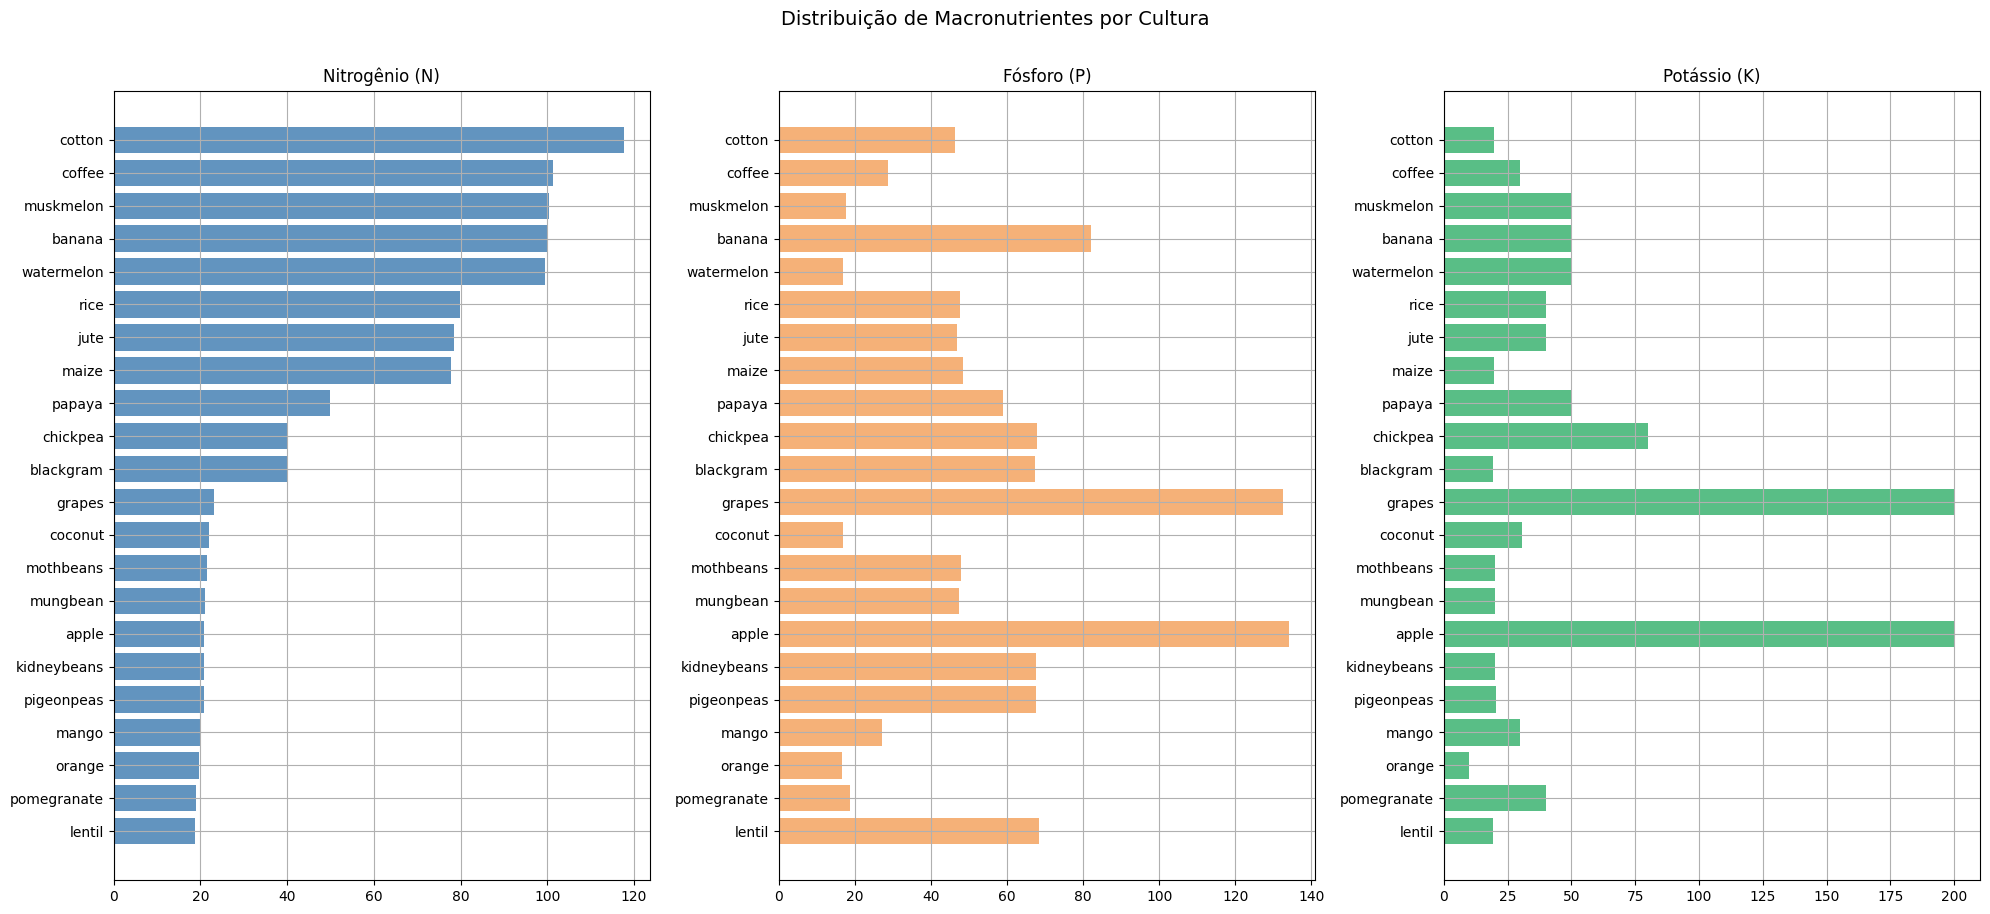

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(20, 9))

nutrientes = ['N', 'P', 'K']
nomes      = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)']
cores = ['steelblue', 'sandybrown', 'mediumseagreen']

ordenar = df.groupby('label')['N'].mean().sort_values().index

for ax, col, nome, cor in zip(axes, nutrientes, nomes, cores):
    medias = df.groupby('label')[col].mean().reindex(ordenar)
    ax.barh(medias.index, medias.values,
            color=cor, alpha=0.85)
    ax.set_title(nome)
    ax.grid()

plt.suptitle('Distribuição de Macronutrientes por Cultura', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#2.Quais culturas preferem temperaturas mais baixas?

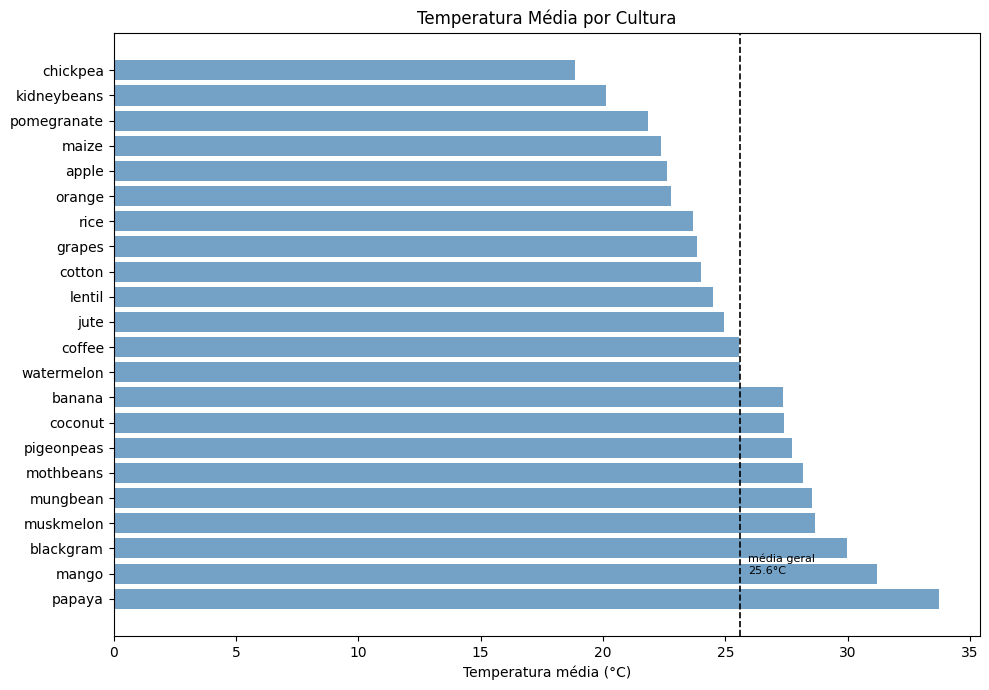

Maiores temperaturas: 
label
papaya       33.723859
mango        31.208770
blackgram    29.973340
muskmelon    28.663066
mungbean     28.525775
Name: temperature, dtype: float64


In [224]:
media_temp = df.groupby('label')['temperature'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(media_temp.index, media_temp.values, color='steelblue', alpha=0.75)

# linha da media geral
media_geral = df['temperature'].mean()
plt.axvline(media_geral, color='black', linestyle='--', linewidth=1.2)
plt.text(media_geral + 0.3, 1, f'média geral\n{media_geral:.1f}°C', fontsize=8)

plt.xlabel('Temperatura média (°C)')
plt.title('Temperatura Média por Cultura')
plt.tight_layout()
plt.show()



print(f'Maiores temperaturas: \n{media_temp.head(5)}')

#3.Existe correlações entre as variáveis numéricas?


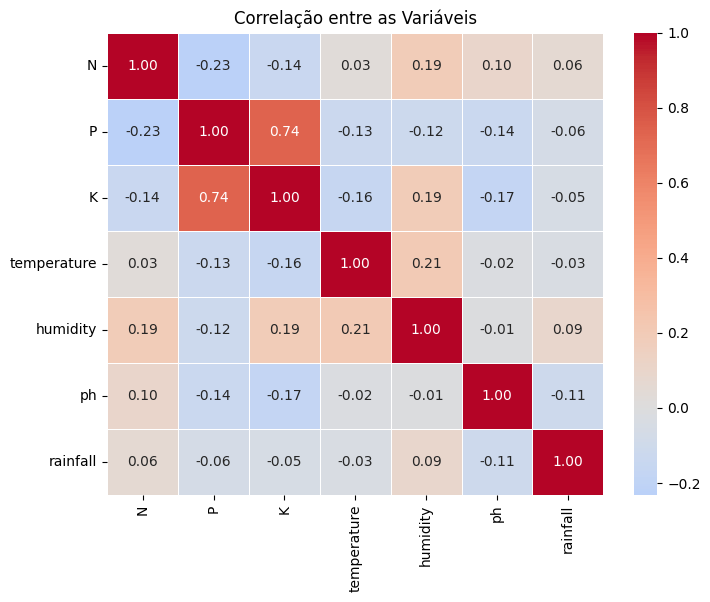

In [225]:
colunas_numericas = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlação entre as Variáveis')
plt.show()

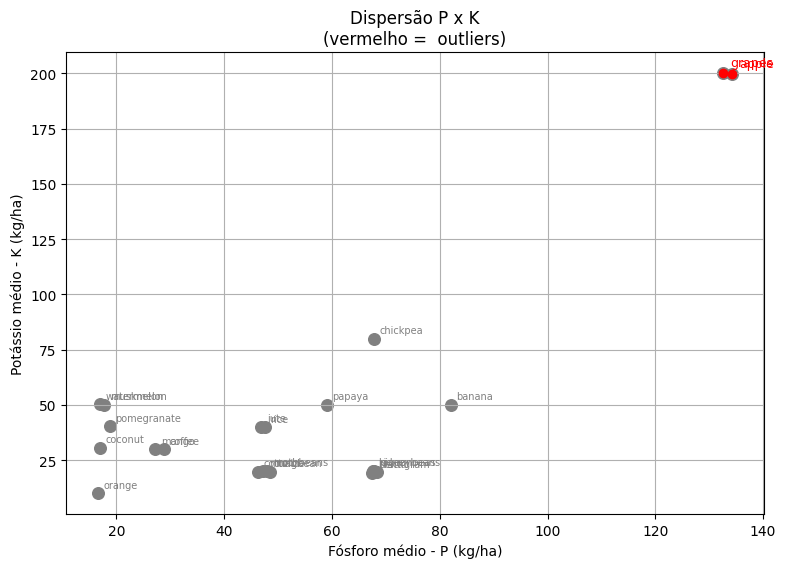

In [242]:

media_P = df.groupby('label')['P'].mean()
media_K = df.groupby('label')['K'].mean()


plt.figure(figsize=(9, 6))

plt.scatter(media_P, media_K, color='gray', s=70)

#Outliers
outliers = ['apple', 'grapes']
for cultura in outliers:
    plt.scatter(media_P[cultura], media_K[cultura], color='red', zorder=3)
    plt.annotate(cultura,
                 xy=(media_P[cultura], media_K[cultura]),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, color='red')


#Outra culturas
for cultura in media_P.index:
    if cultura not in outliers:
        plt.annotate(cultura,
                     xy=(media_P[cultura], media_K[cultura]),
                     xytext=(4, 4), textcoords='offset points',
                     fontsize=7, color='gray')


plt.xlabel('Fósforo médio - P (kg/ha)')
plt.ylabel('Potássio médio - K (kg/ha)')
plt.title('Dispersão P x K\n(vermelho =  outliers)')
plt.grid()
plt.show()

#4. Como a umidade varia entre as culturas?

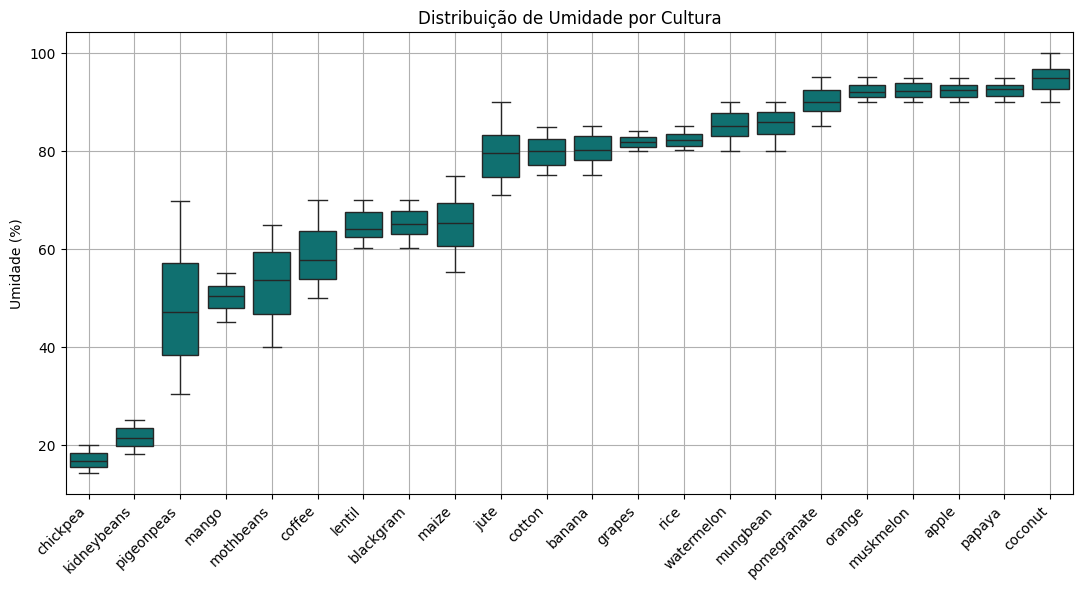

In [227]:
#mediana da umidade
ordem_umidade = df.groupby('label')['humidity'].median().sort_values().index.tolist()


plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x='label', y='humidity', order=ordem_umidade, color='teal')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Umidade (%)')
plt.title('Distribuição de Umidade por Cultura')
plt.grid()

plt.show()

#5. Quais culturas precisam de mais chuva?

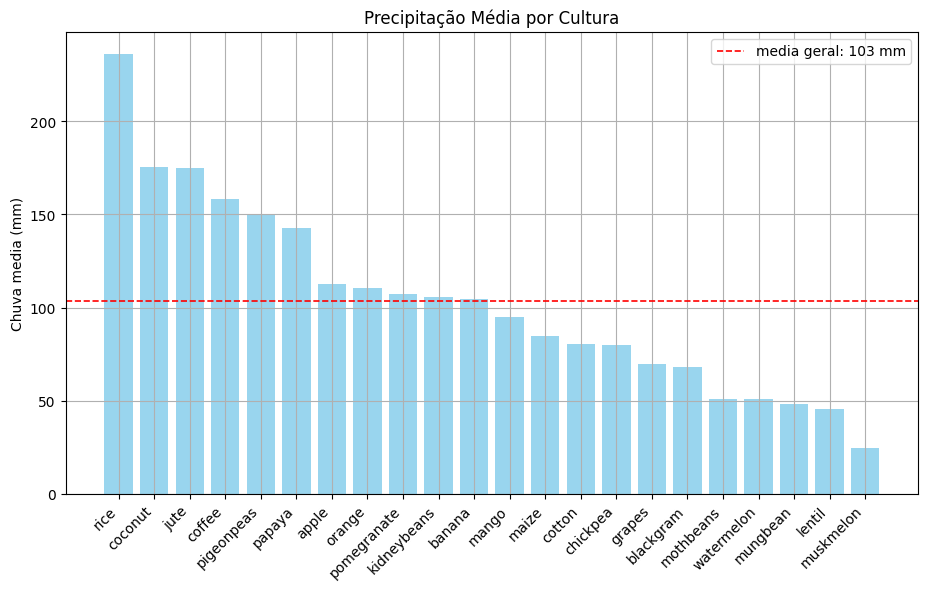

In [230]:
media_chuva = df.groupby('label')['rainfall'].mean().sort_values(ascending=False)


plt.figure(figsize=(11, 6))
plt.bar(media_chuva.index, media_chuva.values, color='skyblue', alpha=0.85)
plt.grid()

media_geral_chuva = media_chuva.mean()
plt.axhline(media_geral_chuva, color='red', linestyle='--', linewidth=1.2,
            label=f'média geral: {media_geral_chuva:.0f} mm')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Chuva media (mm)')
plt.title('Precipitação Média por Cultura')
plt.legend()



plt.show()

#6. Como o PH de distribui em cada cultura?

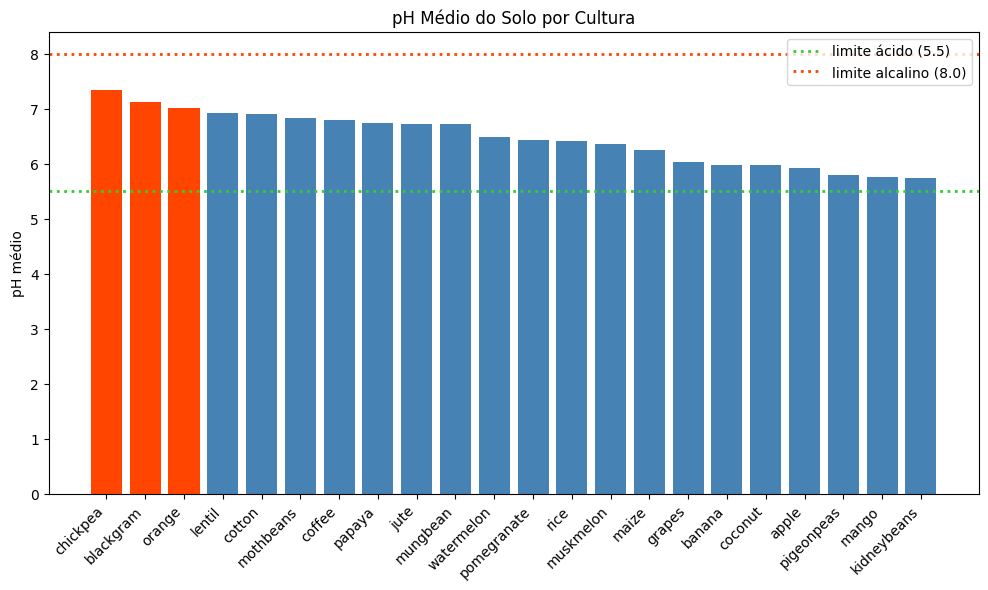

pH médio por cultura:
label
chickpea     7.336957
blackgram    7.133952
orange       7.016957
lentil       6.927932
cotton       6.912675
mothbeans    6.831174
coffee       6.790308
papaya       6.741442
jute         6.732778
mungbean     6.723957
Name: ph, dtype: float64


In [232]:
media_ph = df.groupby('label')['ph'].mean().sort_values(ascending=False)

def tipo_ph(v):
    if v <= 7.0:
        return 'steelblue'   # neutro
    else:
        return 'orangered'   # alcalino

cores_ph = [tipo_ph(v) for v in media_ph.values]

plt.figure(figsize=(12, 6))
plt.bar(media_ph.index, media_ph.values, color=cores_ph)

plt.axhline(5.5, color='limegreen', linestyle=':', linewidth=2, label='limite ácido (5.5)')
plt.axhline(8.0, color='orangered', linestyle=':', linewidth=2, label='limite alcalino (8.0)')

plt.xticks(rotation=45, ha='right')
plt.ylabel('pH médio')
plt.title('pH Médio do Solo por Cultura')
plt.legend()
plt.show()

print('pH médio por cultura:')
print(media_ph.head(10))

#7. Quais culturas tem a maior variação nos dados de temperatura ?

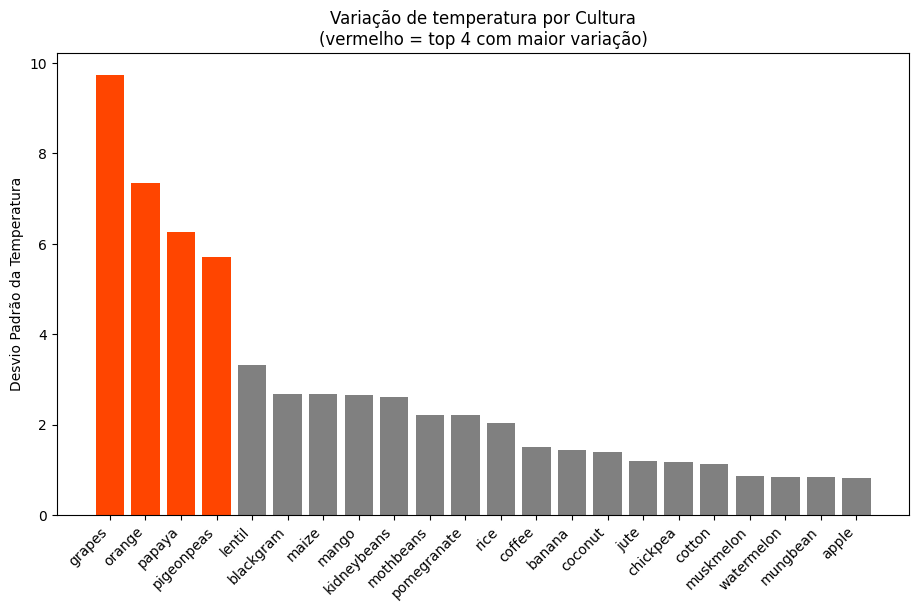

top 5 culturas com maior variação de temperatura: 
label
grapes        9.738649
orange        7.342535
papaya        6.263022
pigeonpeas    5.715682
Name: temperature, dtype: float64


In [236]:
desvio_temp = df.groupby('label')['temperature'].std().sort_values(ascending=False)


plt.figure(figsize=(11, 6))

cores_desvio = ['orangered' if i < 4 else 'gray' for i in range(len(desvio_temp))]

plt.bar(desvio_temp.index, desvio_temp.values, color=cores_desvio)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Desvio Padrão da Temperatura')
plt.title('Variação de temperatura por Cultura\n(vermelho = top 4 com maior variação)')

plt.show()

print('top 5 culturas com maior variação de temperatura: ')
print(desvio_temp.head(4))

#8.Quais culturas tem clima mais exigentes?

/tmp/ipykernel_3270/783262196.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


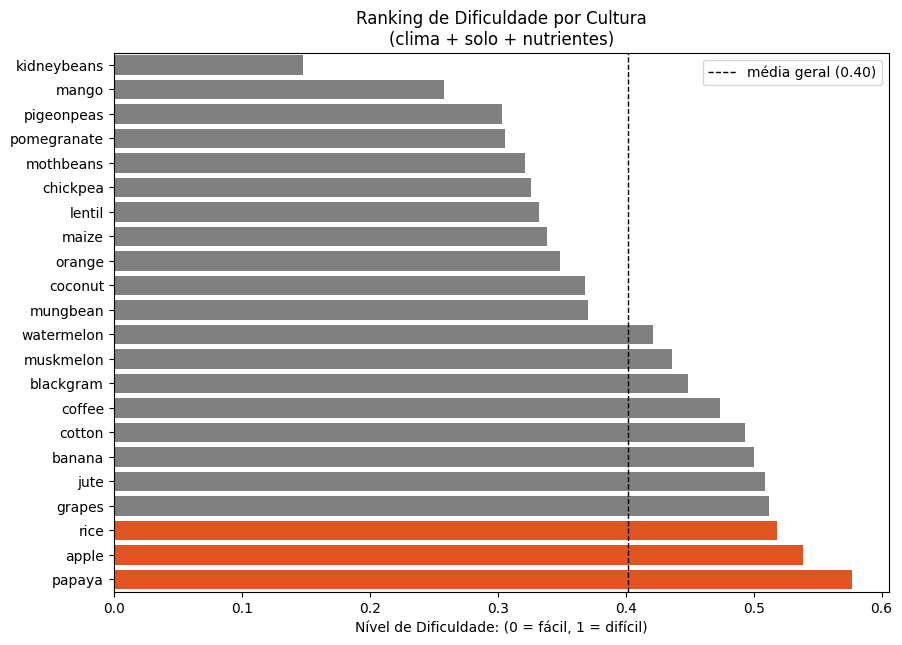

As 3 culturas mais difíceis de plantar:
          Nível de dificuldade
label
rice      0.518160
apple     0.538525
papaya    0.576747
dtype: float64

As 3 culturas mais fáceis de plantar:
          Nível de dificuldade
label
kidneybeans    0.147817
mango          0.258221
pigeonpeas     0.303464
dtype: float64


In [237]:
colunas = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# media de cada variavel por cultura
medias = df.groupby('label')[colunas].mean()

normalizado = (medias - medias.min()) / (medias.max() - medias.min())

normalizado = normalizado.mean(axis=1)
normalizado = normalizado.sort_values()


cores = []
for i in range(len(normalizado)):
    if i >= len(normalizado) - 3:
        cores.append('orangered')
    else:
        cores.append('gray')

# Gráfico de barras:

plt.figure(figsize=(10, 7))
sns.barplot(
    x=normalizado,
    y=normalizado.index,
    palette=cores,
  )

#média geral
media_score = normalizado.mean()
plt.axvline(media_score, color='black', linestyle='--', linewidth=1,
            label=f'média geral ({media_score:.2f})')


plt.xlabel('Nível de Dificuldade: (0 = fácil, 1 = difícil)')
plt.ylabel('')
plt.title('Ranking de Dificuldade por Cultura\n(clima + solo + nutrientes)')
plt.legend()
plt.show()

print('As 3 culturas mais difíceis de plantar:')
print('          Nível de dificuldade')
print(normalizado.tail(3))
print("")
print('As 3 culturas mais fáceis de plantar:')
print('          Nível de dificuldade')
print(normalizado.head(3))